# Clustering Overview

What is **clustering**?
- it's unsupervised - doesn't require labels
- tries to group the datapoints into similar subsets

5 Key Types of Clustering
1. Centroid-based $\rightarrow$ *K-Means*
2. Distribution-based $\rightarrow$ *Mixture Models*
3. Density-based $\rightarrow$ *DBSCAN*
4. Hierarchical-based $\rightarrow$ *Dendrogram*
5. Graph-based $\rightarrow$ *Spectral Clustering*

---

# K-Means

The **K-Means** algorithm tries to partition data samples into $K$ distinct subgroups where each datapoint has membership in *only one* cluster.
- **iterative** algorithm
- **centroid based** - each point is assigned to the cluster whose centroid is the closest
- tries to make *intra-cluster* distances small by minimizing the distance from samples in a cluster and their relative centroid

---

## K-Means Optimization

### Objective

**K-means Objective Function**
\begin{align*}
J(\Theta,U) &= \sum_{n=1}^N\sum_{k=1}^K u_{nk} d^2\left(\mathbf{x}_n, \theta_k\right)\\
&= \sum_{n=1}^N\sum_{k=1}^K u_{nk} \Vert \mathbf{x}_n - \theta_k\Vert_2^2\\
\text{ such that } & u_{nk}\in\{0,1\}\text{ and }\sum_{k=1}^K u_{nk} = 1
\end{align*}

where $u_{nk}$ are cluster assignments, $\theta_k$ is the $k^{th}$ cluster representative and $d\left(\mathbf{x}_n,\theta_k\right)$ is the distance between data point $\mathbf{x}_n$ and cluster centroid $\theta_k$.

### Optimization

K-Means aims to optimize
\begin{align*}
\arg_{\Theta,U}\min J(\Theta,U)
\end{align*}
**Expectation Maximization** can be used to solve this optimization problem.
- The K-Means algorithm aims to uncover the hidden structure of the samples. The cluster assignment variable can be viewed as a latent variable.

**E-step** - assign hard cluster memberships
\begin{align*}
u_{nk} &= \begin{cases} 1 & \text{if } k=\arg\min_k \Vert \mathbf{x}_n - \theta_k\Vert_2^2 \\ 0 & \text{otherwise}  \end{cases}
\end{align*}

**M-step** - solves for new cluster centroids

For the first iteration, the cluster centroids are randomly initialized.
\begin{align*}
J(\Theta,U) &= \sum\limits_{n=1}^N u_{nk} \left(\mathbf{x}_n-\theta_k\right)^T\left(\mathbf{x}_n-\theta_k\right)\\
 &= \sum\limits_{n=1}^N u_{nk} \left(\mathbf{x}_n^T\mathbf{x}_n-\mathbf{x}_n^T\theta_k-\theta_k^T\mathbf{x}_n+\theta_k^T\theta_k\right)\\
 &= \sum\limits_{n=1}^N u_{nk} \left(\mathbf{x}_n^T\mathbf{x}_n-2\theta_k^T\mathbf{x}_n+\theta_k^T\theta_k\right)\\
\frac{\partial J(\Theta,U)}{\partial \Theta} &= 0\\
-2 \sum\limits_{n=1}^N u_{nk} \left(\mathbf{x}_n-\theta_k\right) &= 0\\
\sum\limits_{n=1}^N u_{nk}\mathbf{x}_n = \sum_{n=1}^N u_{nk}\theta_k\\
\sum\limits_{n=1}^N u_{nk}\mathbf{x}_n = \theta_k\sum\limits_{n=1}^N u_{nk}\\
\theta_k = \frac{\sum\limits_{n=1}^N u_{nk}\mathbf{x}_n}{\sum\limits_{n=1}^N u_{nk}} \\
\theta_k = \frac{\sum\limits_{n=1}^N u_{nk}\mathbf{x}_n}{N_k} \\
\theta_k = \frac{\sum\limits_{\mathbf{x}_n\in C_k} \mathbf{x}_n}{N_k} \\
\end{align*}

where $N_k = \sum\limits_{n=1}^N u_{nk}$ is the number of all data points assigned to cluster $C_k$, and $\sum\limits_{\mathbf{x}_n\in C_k} \mathbf{x}_n=\sum\limits_{n=1}^N u_{nk}\mathbf{x}_n$ is the sum of data points that are assigned to cluster $C_k$.

---

## Pseudocode

---
**Algorithm 1:** K-Means Algorithm

1. Set number of clusters, K
2. Initialize cluster centers, $\{\theta_k\}_{k=1}^K$, and cluster memberships, $\{\mathbf{u}_n\}_{n=1}^N$
3. **repeat**  
4. &nbsp;&nbsp;&nbsp;&nbsp;**for** $n = 1 \ \text{to} \ N$ **do**  
5. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Determine the closest cluster representative, $\theta_k$, to $\mathbf{x}_n$
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Set label $u_{nk} = 1$ for closest cluster $C_k$
7. &nbsp;&nbsp;&nbsp;&nbsp; **end for**  
8. &nbsp;&nbsp;&nbsp;&nbsp;**for** $k = 1 \ \text{to} \ K$ **do**  
9. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Update cluster center, $\theta_k$, to the mean of points in cluster $C_k$, *i.e.* $\theta_k = \frac{\sum\limits_{\mathbf{x}_n \in C_k} \mathbf{x}_n}{N_k}$
10. &nbsp;&nbsp;&nbsp;&nbsp;**end for**  
11. **until** change in cluster centers is small
---

---

## Examples

### Stepping through updates

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from scipy.spatial.distance import cdist
import seaborn as sns

# Set style for prettier plots
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)  # This scales all fonts by 1.2x

plt.rcParams.clear()
plt.rcParams['font.size'] = 14

def KMeans_with_visualization(X, K, MaxIter=100, Thresh=1e-5, metric='euclidean'):
    '''K-Means algorithm implementation with step-by-step visualization'''
    N = X.shape[0]
    rp = np.random.permutation(N)
    centers = X[rp[0:K], :]
    
    # Show initial random centroids
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c='lightblue', alpha=0.7, s=20)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3)
    plt.title(f'Step 0: Randomly select K={K} data points as initial centroids')
    plt.grid(True, alpha=0.3)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.xlim(X.min()-1, X.max()+1)
    plt.ylim(X.min()-1, X.max()+1)
    plt.show()
    
    diff = np.inf
    iteration = 0
    
    while (diff > Thresh) & (iteration < MaxIter):
        iteration += 1
        
        # Compute distances and assign to closest cluster
        D = cdist(X, centers, metric=metric)
        L = np.argmin(D, axis=1)
        
        # Visualization of assignment step
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Left plot: Show assignments
        scatter = axes[0].scatter(X[:, 0], X[:, 1], c=L, cmap='viridis', alpha=0.7, s=20)
        axes[0].scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3)
        axes[0].set_title(f'Step {iteration}a: Assign points to closest centroid')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('Y')
        axes[0].set_xlim(X.min()-1, X.max()+1)
        axes[0].set_ylim(X.min()-1, X.max()+1)

        # Update cluster centers
        centersPrev = centers.copy()
        for i in range(K):
            if np.sum(L == i) > 0:  # Avoid empty clusters
                centers[i, :] = np.mean(X[L == i, :], axis=0)
        
        # Right plot: Show updated centroids
        axes[1].scatter(X[:, 0], X[:, 1], c=L, cmap='viridis', alpha=0.7, s=20)
        axes[1].scatter(centersPrev[:, 0], centersPrev[:, 1], c='orange', marker='x', s=200, linewidths=3, label='Old centroids')
        axes[1].scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3, label='New centroids')
        
        # Draw arrows showing centroid movement
        for i in range(K):
            axes[1].annotate('', xy=centers[i], xytext=centersPrev[i],
                           arrowprops=dict(arrowstyle='->', color='black', lw=2))
        
        axes[1].set_title(f'Step {iteration}b: Update centroids to cluster means')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlabel('X')
        axes[1].set_ylabel('Y')
        axes[1].set_xlim(X.min()-1, X.max()+1)
        axes[1].set_ylim(X.min()-1, X.max()+1)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Check convergence
        diff = np.linalg.norm(centersPrev - centers)
        print(f"Iteration {iteration} complete.")
    
    return centers, L

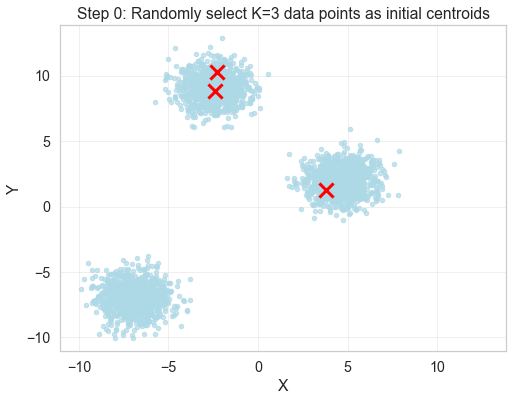

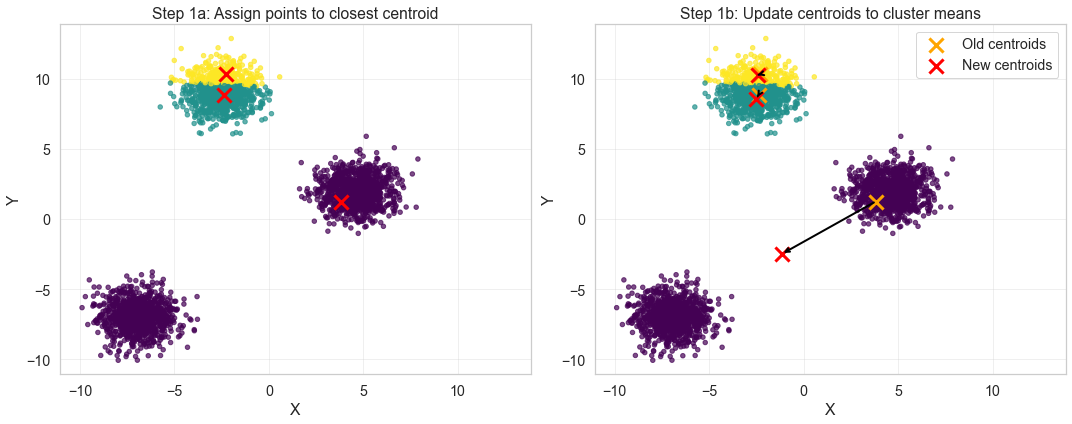

Iteration 1 complete.


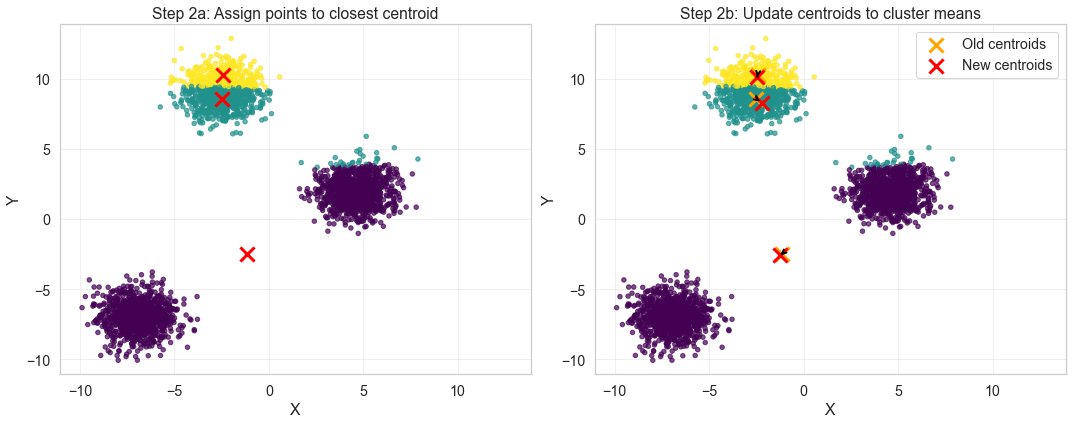

Iteration 2 complete.


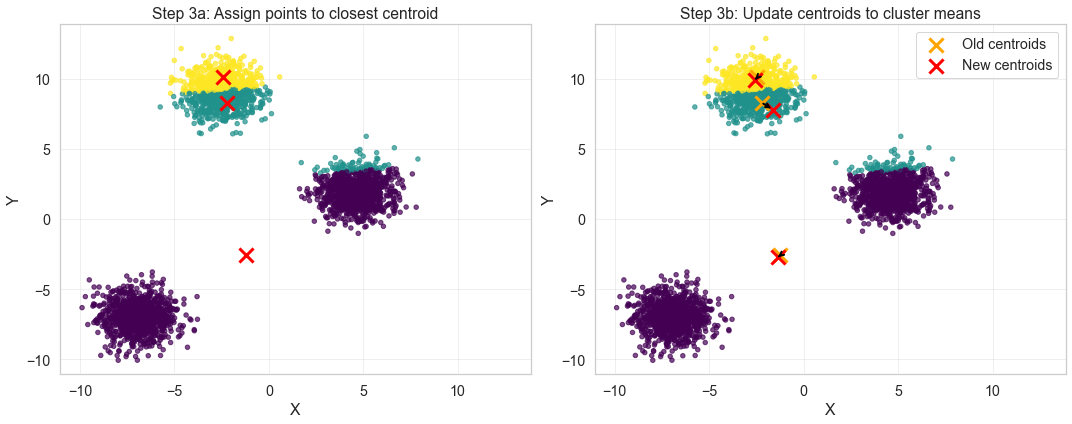

Iteration 3 complete.


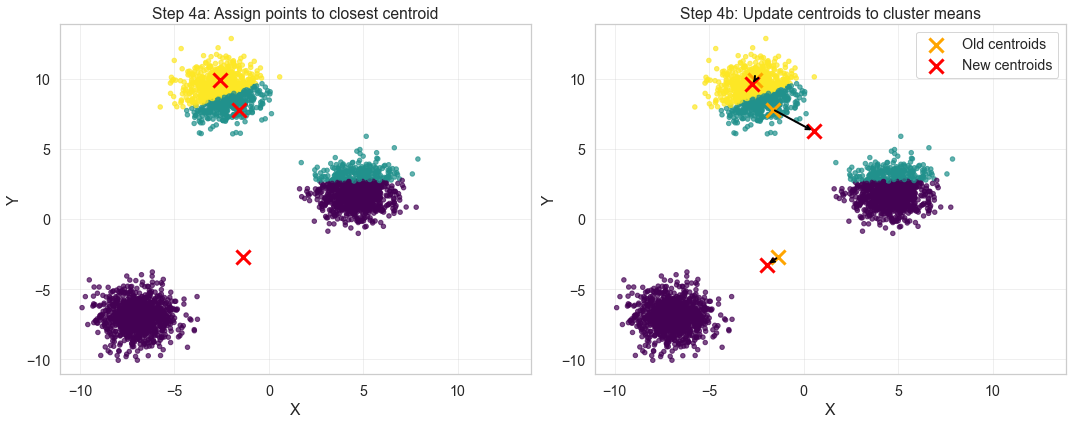

Iteration 4 complete.


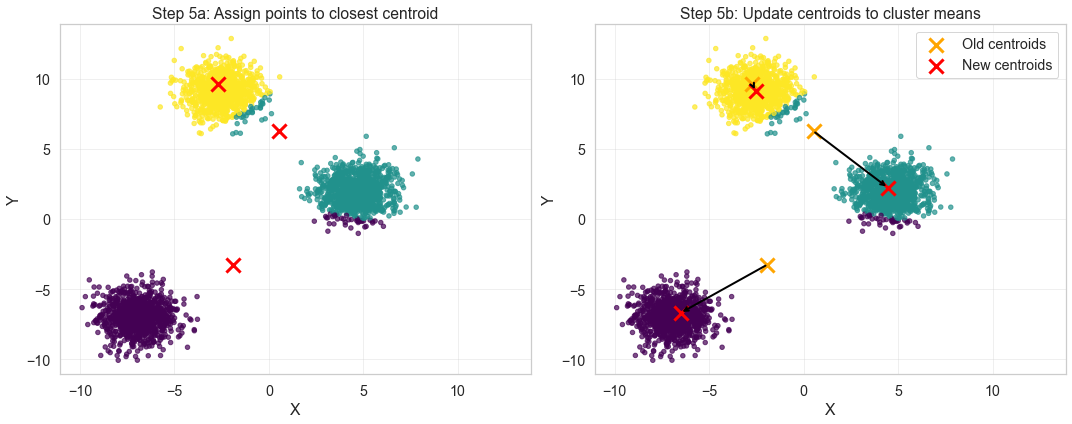

Iteration 5 complete.


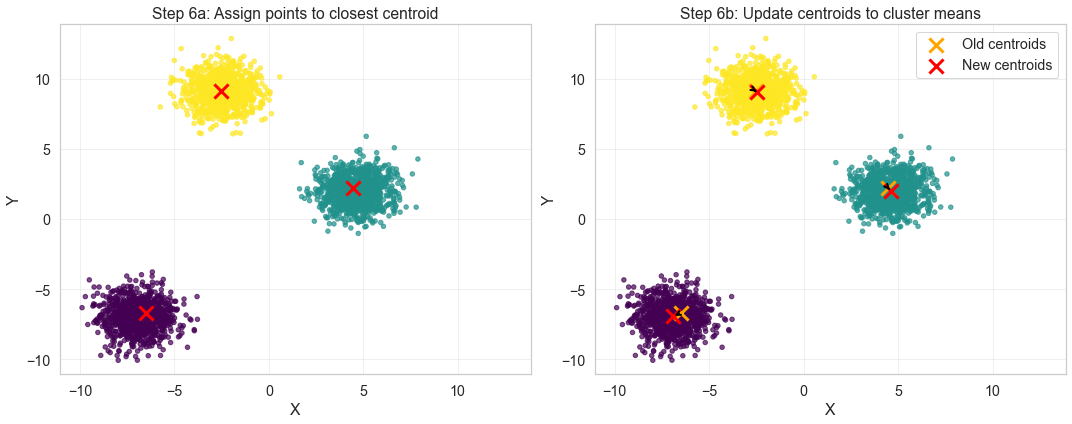

Iteration 6 complete.


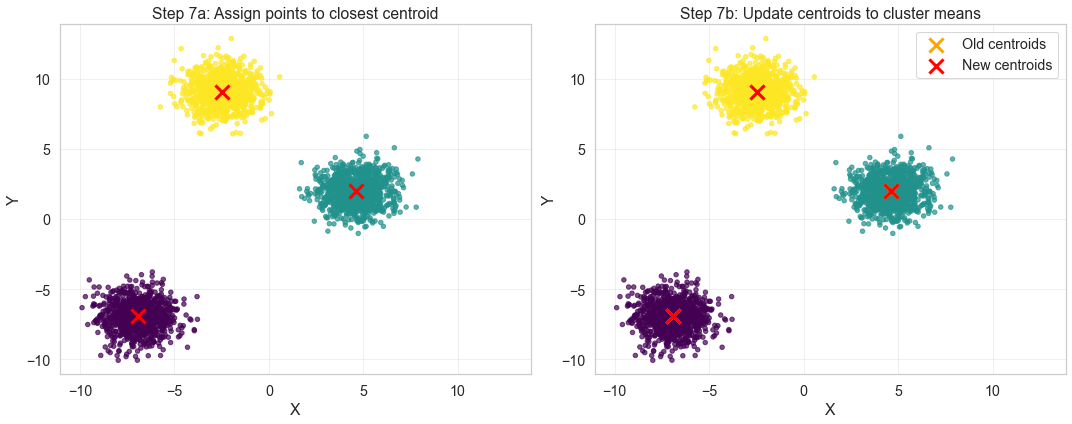

Iteration 7 complete.


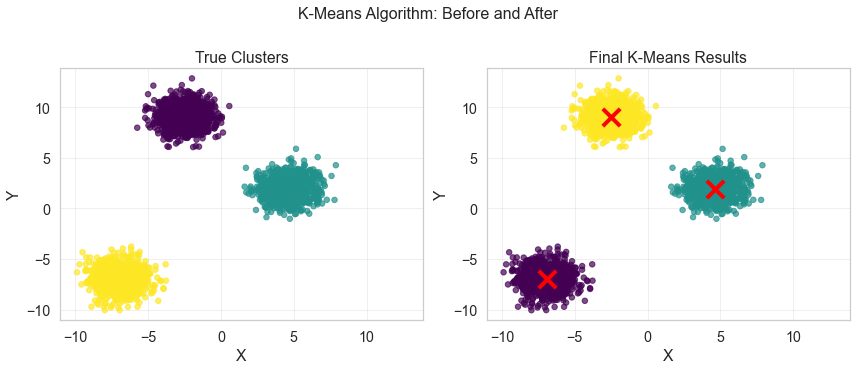

In [2]:
# Generate regular blobs dataset
np.random.seed(42)
# np.random.seed(5)
n_samples = 3000  # Smaller for clearer visualization
X1, T1 = datasets.make_blobs(n_samples=n_samples, centers=3, cluster_std=1, random_state=42)

# Run K-Means with visualization
NoClusters = 3
centers, kmeans_labels = KMeans_with_visualization(X1, NoClusters)

# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True clusters
axes[0].scatter(X1[:, 0], X1[:, 1], c=T1, cmap='viridis', alpha=0.7, s=30)
axes[0].set_title('True Clusters')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_xlim(X1.min()-1, X1.max()+1)
axes[0].set_ylim(X1.min()-1, X1.max()+1)


# Final K-Means results
axes[1].scatter(X1[:, 0], X1[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, s=30)
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=300, linewidths=4)
axes[1].set_title('Final K-Means Results')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_xlim(X1.min()-1, X1.max()+1)
axes[1].set_ylim(X1.min()-1, X1.max()+1)

plt.suptitle('K-Means Algorithm: Before and After', fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

Why are equally sized spherical clusters the ideal cluster shape for K-Means?

### Failure Cases and Comparison of with GMMs

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import seaborn as sns
import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.cluster import KMeans # For general structure, though you'll customize distance

plt.rcParams['font.size'] = 14

# Set style for prettier plots
sns.set_style("whitegrid")
np.random.seed(42)

def generate_different_sized_blobs():
    """Generate clusters of very different sizes"""
    # Small, dense cluster
    cluster1 = np.random.multivariate_normal([2, 2], [[0.1, 0], [0, 0.1]], 150)
    
    # Large, sparse cluster  
    cluster2 = np.random.multivariate_normal([6, 6], [[2, 0], [0, 2]], 800)
    
    # Medium cluster
    cluster3 = np.random.multivariate_normal([2, 8], [[0.5, 0], [0, 0.5]], 350)
    
    data = np.vstack([cluster1, cluster2, cluster3])
    true_labels = np.hstack([np.zeros(150), np.ones(800), np.full(350, 2)])
    
    return data, true_labels

def generate_anisotropic_blobs():
    """Generate elongated, non-spherical clusters"""
    # Diagonal elongated cluster
    cluster1 = np.random.multivariate_normal([2, 2], [[2, 1.5], [1.5, 2]], 500)
    
    # Horizontal elongated cluster
    cluster2 = np.random.multivariate_normal([8, 2], [[3, 0], [0, 0.3]], 500)
    
    # Vertical elongated cluster
    cluster3 = np.random.multivariate_normal([5, 7], [[0.3, 0], [0, 3]], 500)
    
    data = np.vstack([cluster1, cluster2, cluster3])
    true_labels = np.hstack([np.zeros(500), np.ones(500), np.full(500, 2)])
    
    return data, true_labels

def generate_extremely_anisotropic_blobs():
    """Generate EXTREMELY elongated clusters that really challenge K-Means"""
    
    # Extremely thin horizontal sausage
    cluster1 = np.random.multivariate_normal([2, 2], [[8.0, 0], [0, 0.05]], 500)
    
    # Extremely thin vertical sausage
    cluster2 = np.random.multivariate_normal([8, 2], [[0.05, 0], [0, 6.0]], 500)
    
    # Extremely thin diagonal sausage (rotated)
    # Create a thin horizontal cluster first, then rotate it
    base_cluster = np.random.multivariate_normal([0, 0], [[6.0, 0], [0, 0.08]], 500)
    # Rotation matrix for 45 degrees
    angle = np.pi / 4
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                               [np.sin(angle), np.cos(angle)]])
    cluster3 = (rotation_matrix @ base_cluster.T).T + [5, 7]  # Rotate and translate
    
    data = np.vstack([cluster1, cluster2, cluster3])
    true_labels = np.hstack([np.zeros(500), np.ones(500), np.full(500, 2)])
    
    return data, true_labels

def generate_non_spherical_shapes():
    """Generate crescent/moon shapes that are clearly non-spherical"""
    from sklearn.datasets import make_moons, make_circles
    
    # Two moons
    moons, moon_labels = make_moons(n_samples=1000, noise=0.15, random_state=42)
    
    # Nested circles
    circles, circle_labels = make_circles(n_samples=1000, noise=0.1, factor=0.3, random_state=42)
    circles[:, 0] += 4  # Shift circles to avoid overlap
    
    return moons, moon_labels, circles, circle_labels

def plot_clustering_comparison(data, true_labels, kmeans_labels, gmm_labels, title):
    """Plot true clusters vs K-Means vs GMM results"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # True clusters
    scatter1 = axes[0].scatter(data[:, 0], data[:, 1], c=true_labels, cmap='viridis', alpha=0.7)
    axes[0].set_title('True Clusters')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_xlim(data.min()-1, data.max()+1)
    axes[0].set_ylim(data.min()-1, data.max()+1)
    
    # K-Means results
    scatter2 = axes[1].scatter(data[:, 0], data[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
    axes[1].set_title('K-Means Results')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_xlim(data.min()-1, data.max()+1)
    axes[1].set_ylim(data.min()-1, data.max()+1)
    
    # GMM results
    scatter3 = axes[2].scatter(data[:, 0], data[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7)
    axes[2].set_title('GMM Results')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    axes[2].set_xlim(data.min()-1, data.max()+1)
    axes[2].set_ylim(data.min()-1, data.max()+1)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    return fig

def plot_non_spherical_comparison(data, true_labels, kmeans_labels, gmm_labels, title):
    """Plot comparison for non-spherical data including GMM"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # True clusters
    axes[0].scatter(data[:, 0], data[:, 1], c=true_labels, cmap='viridis', alpha=0.7)
    axes[0].set_title('True Clusters')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_xlim(data.min()-1, data.max()+1)
    axes[0].set_ylim(data.min()-1, data.max()+1)    

    # K-Means results
    axes[1].scatter(data[:, 0], data[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
    axes[1].set_title('K-Means Results')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_xlim(data.min()-1, data.max()+1)
    axes[1].set_ylim(data.min()-1, data.max()+1)
    
    # GMM results
    axes[2].scatter(data[:, 0], data[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7)
    axes[2].set_title('GMM Results')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    axes[2].set_xlim(data.min()-1, data.max()+1)
    axes[2].set_ylim(data.min()-1, data.max()+1)

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    return fig

def mahalanobis_distance_metric(x, y, VI):
    return mahalanobis(x, y, VI)

# Example of a basic custom K-means loop (simplified)
def custom_kmeans_mahalanobis(data, n_clusters, cov, max_iter=100):
    # Initialize centroids randomly
    centroids = data[np.random.choice(data.shape[0], n_clusters, replace=False)]

    inverse_covariance_matrix = np.linalg.inv(cov)

    for _ in range(max_iter):
        # Assignment step
        labels = np.zeros(data.shape[0])
        for i, point in enumerate(data):
            distances = [mahalanobis_distance_metric(point, centroid, inverse_covariance_matrix) for centroid in centroids]
            labels[i] = np.argmin(distances)

        # Update step
        new_centroids = np.array([data[labels == j].mean(axis=0) for j in range(n_clusters)])

        # Check for convergence (simplified)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

Generating visualizations of K-Means limitations
1. Different sized clusters


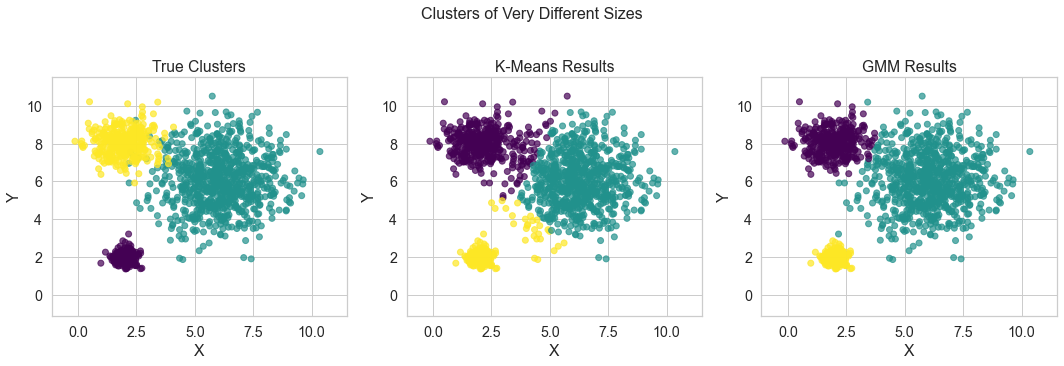

In [4]:
# Generate and plot different scenarios
print("Generating visualizations of K-Means limitations")

# Scenario 1: Different sized blobs
print("1. Different sized clusters")
data1, true_labels1 = generate_different_sized_blobs()
kmeans1 = KMeans(n_clusters=3, random_state=42, n_init=10)
gmm1 = GaussianMixture(n_components=3, random_state=42)

kmeans_labels1 = kmeans1.fit_predict(data1)
gmm_labels1 = gmm1.fit_predict(data1)

fig1 = plot_clustering_comparison(data1, true_labels1, kmeans_labels1, gmm_labels1, 
                                 "Clusters of Very Different Sizes")
plt.show()

K-Means struggles with blobs of different sizes because it expects clusters to have the same size and same variance. GMMs loosen this expectation by incorporating the prior $\pi_k$ and can model differences in cluster size. Thus, they can handle different sized blobs better.

2. EXTREMELY Elongated clusters


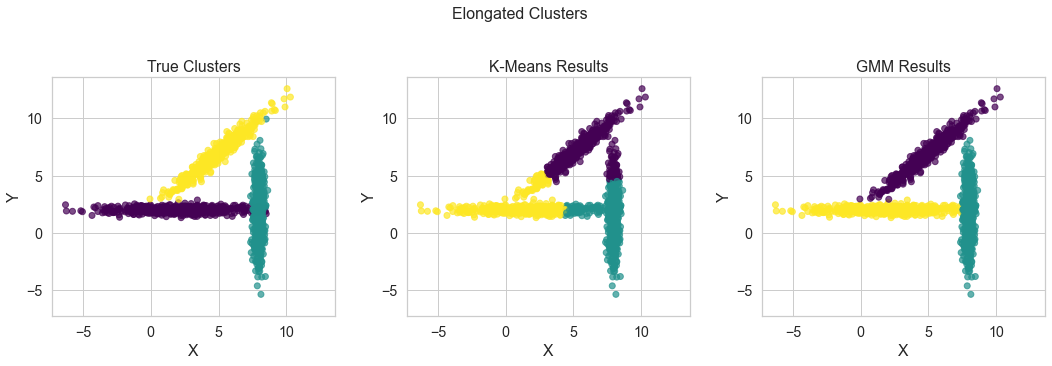

In [5]:
# Scenario 2: EXTREMELY elongated blobs
print("2. EXTREMELY Elongated clusters")
data2, true_labels2 = generate_extremely_anisotropic_blobs()

kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10)
gmm2 = GaussianMixture(n_components=3, random_state=42)

kmeans_labels2 = kmeans2.fit_predict(data2)
gmm_labels2 = gmm2.fit_predict(data2)

fig2 = plot_clustering_comparison(data2, true_labels2, kmeans_labels2, gmm_labels2,
                                  "Elongated Clusters")
plt.show()

K-Means assumes all clusters have equal variance leading to it struggling with elongated/elliptical blobs. Since GMMs consider covariance, they can handle ellipsoidal shapes.

3. Non-spherical shapes: Moons


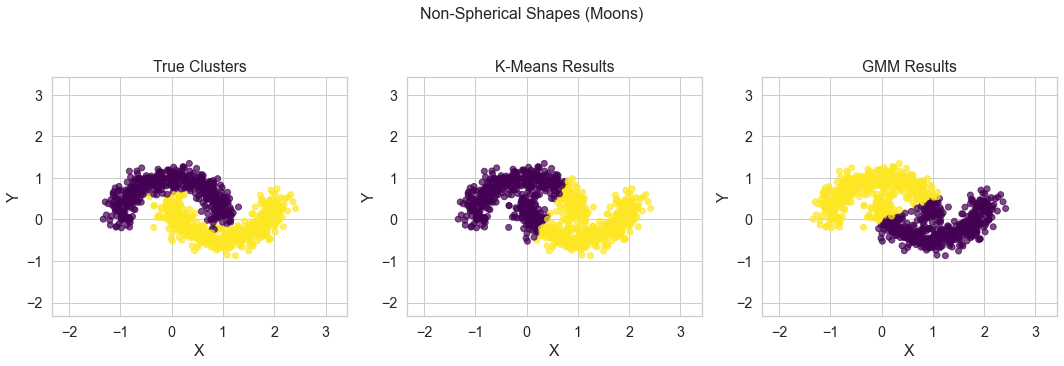

In [6]:
# Scenario 3: Non-spherical shapes
print("3. Non-spherical shapes: Moons")
moons, moon_labels, circles, circle_labels = generate_non_spherical_shapes()

# Plot moons with GMM included
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
gmm_moons = GaussianMixture(n_components=2, random_state=42)

kmeans_moon_labels = kmeans_moons.fit_predict(moons)
gmm_moon_labels = gmm_moons.fit_predict(moons)

fig3 = plot_non_spherical_comparison(moons, moon_labels, kmeans_moon_labels, gmm_moon_labels,
                                   "Non-Spherical Shapes (Moons)")
plt.show()

---

## Applications

### Image Segmentation

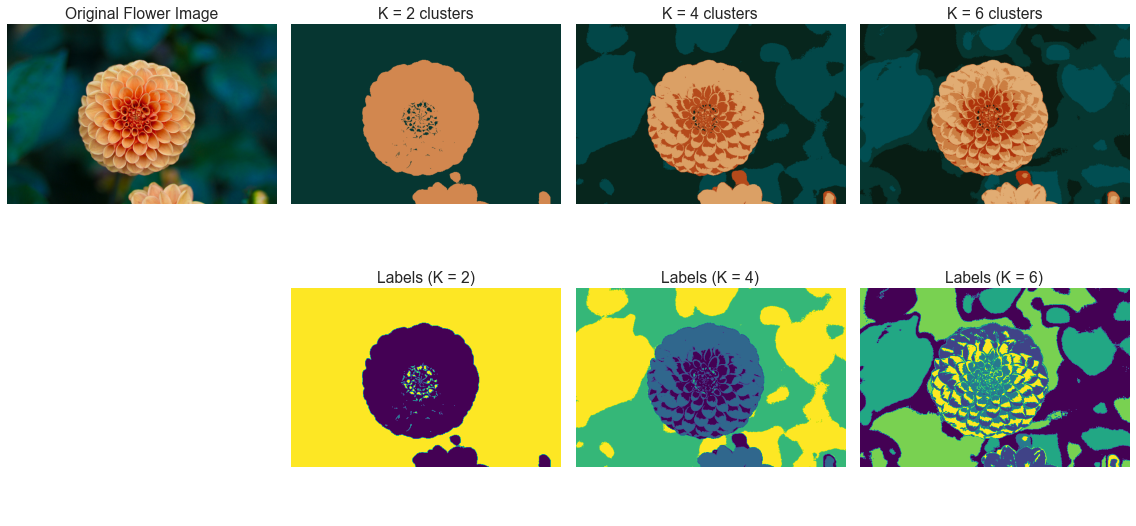

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image

plt.rcParams['font.size'] = 14

def kmeans_segment_real_image(image, k=8):
    """
    Apply K-Means segmentation to a real image.
    """
    # Reshape image to list of pixels
    pixels = image.reshape(-1, 3)
    
    # Apply K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    
    # Create segmented image
    compressed = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)
    labels_2d = labels.reshape(image.shape[:2])
    
    return compressed, labels_2d, kmeans.cluster_centers_

flower = load_sample_image("flower.jpg")

# Try different K values
k_values = [2, 4, 6]

fig, axes = plt.subplots(2, len(k_values) + 1, figsize=(16, 8))

axes[0, 0].imshow(flower)
axes[0, 0].set_title("Original Flower Image")
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# Apply K-Means with different K values
for i, k in enumerate(k_values):
    compressed, labels, centers = kmeans_segment_real_image(flower, k=k)
    
    axes[0, i + 1].imshow(compressed)
    axes[0, i + 1].set_title(f"K = {k} clusters")
    axes[0, i + 1].axis('off')
    
    axes[1, i + 1].imshow(labels, cmap='viridis')
    axes[1, i + 1].set_title(f"Labels (K = {k})")
    axes[1, i + 1].axis('off')

plt.tight_layout()
plt.show()

### Image Compression

=== Image Compression Analysis ===
Original unique feature values: 96,615
Compressed to: 16 feature values
Compression ratio: 6038x


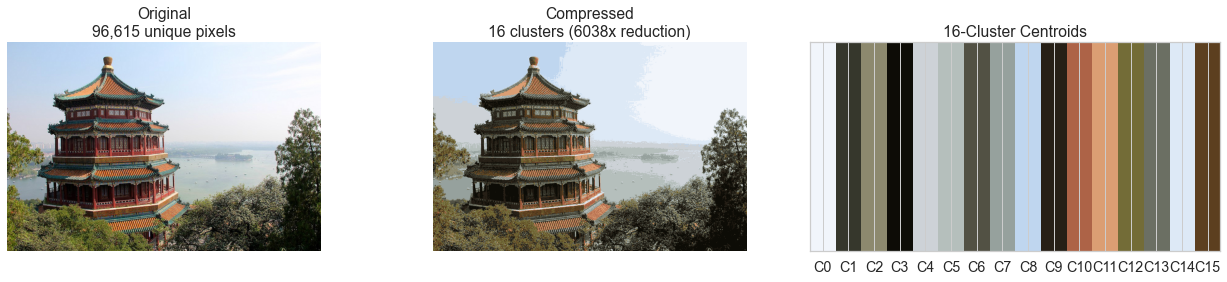

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image

plt.rcParams['font.size'] = 14

def compress_image_kmeans_simple(image, n_cluster=16):
    """
    Compress image and show compression in terms of unique pixels.
    """
    original_shape = image.shape
    pixels = image.reshape(-1, 3)
    
    # Count original unique pixels
    original_unique_pix = len(np.unique(pixels.view(np.dtype((np.void, pixels.dtype.itemsize*pixels.shape[1])))))
    
    # Apply K-Means
    kmeans = KMeans(n_clusters=n_cluster, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    compressed_pixels = kmeans.cluster_centers_[labels]
    compressed_image = compressed_pixels.reshape(original_shape).astype(np.uint8)
    
    # Simple compression ratio
    compression_ratio = original_unique_pix / n_cluster
    
    return compressed_image, {
        'original_unique_pixels': original_unique_pix,
        'compressed_pixels': n_cluster,
        'compression_ratio': compression_ratio,
        'palette': kmeans.cluster_centers_.astype(np.uint8)
    }

n_cluster = 16

# Load sample image and compress to 16 pixels
china = load_sample_image("china.jpg")
compressed, info = compress_image_kmeans_simple(china, n_cluster=16)

print("=== Image Compression Analysis ===")
print(f"Original unique feature values: {info['original_unique_pixels']:,}")
print(f"Compressed to: {info['compressed_pixels']} feature values")
print(f"Compression ratio: {info['compression_ratio']:.0f}x")

# Visualize the results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# Original image
ax1.imshow(china)
ax1.set_title(f"Original\n{info['original_unique_pixels']:,} unique pixels")
ax1.axis('off')

# Compressed image
ax2.imshow(compressed)
ax2.set_title(f"Compressed\n16 clusters ({info['compression_ratio']:.0f}x reduction)")
ax2.axis('off')

# Centroid Features
palette = info['palette'].reshape(1, -1, 3)
ax3.imshow(palette, aspect='auto')
ax3.set_title("16-Cluster Centroids")
ax3.set_xticks(range(16))
ax3.set_xticklabels([f'C{i}' for i in range(16)])
ax3.set_yticks([])

plt.tight_layout()
plt.show()

## Additional discussions

1. Since K-Means uses distances (most commonly the Euclidean distance) to determine similarity of samples, scaling the data is important since features will have different units and scales. Think of age vs income. Which one would dominate?

2. K-Means randomly initializes cluster centroids leading to a different initialization every time. As a result, the output cluster memberships and representatives may differ every time. Further, the algorithm may converge to a local optimum and not the global one. Thus, one should run the algorithm multiple times with different initializations and choose the best result.

3. K-Means with Euclidean distance is a highly constrained version of a GMM. Can you think of how?